In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Sionna 2.x: ray tracing sobre Dr.Jit/Mitsuba — no requiere TensorFlow
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, \
                      PathSolver, RadioMapSolver, Camera

In [18]:
path = "/home/researcher/Downloads/maps/lima01.xml"
scene = load_scene(path)
scene.frequency = 3.5e9  # banda n78 (3.5 GHz), típica para 5G

# verificación: los materiales deben ser itu_* para que Sionna les asigne
# propiedades electromagnéticas
for name, obj in scene.objects.items():
    print(name, "->", obj.radio_material.name)

no-name-5 -> itu-brick
no-name-6 -> itu-concrete
elm__2 -> itu-medium_dry_ground


In [19]:
# Arrays de antenas: BS con 4 elementos verticales patrón 3GPP, UE isotrópico
scene.tx_array = PlanarArray(num_rows=4, num_cols=1,
                             vertical_spacing=0.5, horizontal_spacing=0.5,
                             pattern="tr38901", polarization="V")
scene.rx_array = PlanarArray(num_rows=1, num_cols=1,
                             vertical_spacing=0.5, horizontal_spacing=0.5,
                             pattern="iso", polarization="V")

In [20]:
# Posiciones DENTRO de la escena (bbox: x∈[-660,660], y∈[-416,416], techos ≤55 m)
scene.add(Transmitter("tx", position=[0.0, 0.0, 65.0]))   # BS sobre azotea
scene.add(Receiver("rx",  position=[80.0, 40.0, 1.5]))    # UE peatón

shape a: (2, 1, 1, 1, 4, 3, 1) | shape tau: (1, 1, 3)
trayectos: 3


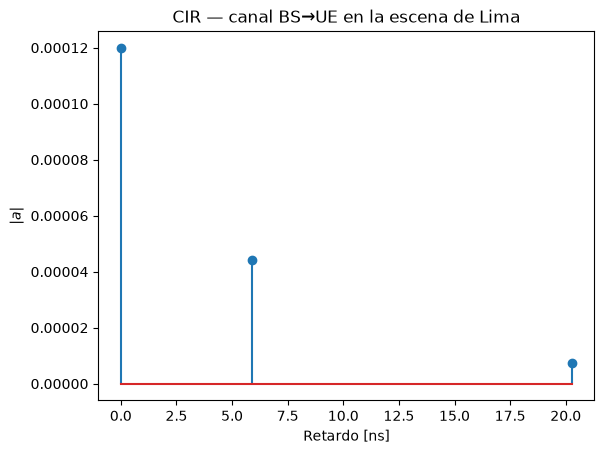

In [21]:
# Trazado de rayos (Sionna 0.x: scene.compute_paths() → 2.x: PathSolver)
paths = PathSolver()(scene, max_depth=3)

# CIR (Sionna 0.x: Paths2CIR → 2.x: método paths.cir())
# a: [rx, ant_rx, tx, ant_tx, paths, t] — tau: [rx, tx, paths]
a, tau = paths.cir()
a, tau = np.array(a), np.array(tau)
print("shape a:", a.shape, "| shape tau:", tau.shape)

# potencia por trayecto: colapsar todas las dims menos la de trayectos
p = np.abs(a)**2
p_path = p.sum(axis=tuple(i for i in range(p.ndim) if i != p.ndim - 2))
print("trayectos:", tau.ravel().size)

plt.figure()
plt.stem(tau.ravel()*1e9, np.sqrt(p_path))
plt.xlabel("Retardo [ns]")
plt.ylabel(r"$|a|$")
plt.title("CIR — canal BS→UE en la escena de Lima")
plt.show()

In [22]:
# Mapa de cobertura (Sionna 0.x: scene.coverage_map() → 2.x: RadioMapSolver)
# ponytail: 10**5 muestras para probar rápido en CPU; para figura final usa 10**6
rm = RadioMapSolver()(scene, max_depth=3, cell_size=(5.0, 5.0),
                      samples_per_tx=10**5)

In [23]:
# Render a archivo — cámara explícita (camera="preview" solo sirve con el
# widget interactivo abierto)
cam = Camera(position=[0.0, -700.0, 500.0], look_at=[0.0, 0.0, 0.0])
scene.render_to_file(camera=cam, filename="resultados/cobertura.png",
                     radio_map=rm, paths=paths, resolution=(1280, 720))
print("escrito cobertura.png")

escrito cobertura.png


In [24]:
# Vista 3D interactiva — solo en Jupyter con el kernel corriendo; descomenta:
scene.preview(paths=paths, radio_map=rm)

## Parte 2 — Red de 3 estaciones base: SINR y best server

Una BS sola no tiene interferencia. Con 3, aparece el problema real de diseño:
cada punto del mapa recibe señal de su mejor servidor **e interferencia de las
otras dos**. El mapa de SINR y el de best-server son las dos herramientas
básicas del planificador de red.

In [25]:
# Sitios candidatos (bbox: x∈[-660,660], y∈[-416,416]) — ESTOS son los
# parámetros de diseño: posición, altura, potencia. Muévelos y re-corre.
sites = {
    "bs1": [-380.0,  200.0, 30.0],
    "bs2": [ 350.0,  230.0, 30.0],
    "bs3": [   0.0, -260.0, 30.0],
}
P_TX_DBM = 44.0   # macro urbana típica

# ponytail: elementos isotrópicos para ver la estructura de celdas limpia;
# el paso siguiente del curso es sectorizar con tr38901 + tilt
scene.tx_array = PlanarArray(num_rows=1, num_cols=1,
                             vertical_spacing=0.5, horizontal_spacing=0.5,
                             pattern="iso", polarization="V")

scene.remove("tx")   # fuera la BS de la Parte 1
for name, pos in sites.items():
    scene.add(Transmitter(name, position=pos, power_dbm=P_TX_DBM))

print("transmisores:", list(scene.transmitters.keys()))

transmisores: ['bs1', 'bs2', 'bs3']


In [26]:
# Radio map CONSOLIDADO — línea base oficial del ejercicio.
# Regla: se explora barato (10^5, depth 3), se reporta caro (10^6, depth 5,
# reflexión difusa). Este número es contra el que se comparan los diseños.
rm3 = RadioMapSolver()(scene, max_depth=5, cell_size=(5.0, 5.0),
                       samples_per_tx=10**6, diffuse_reflection=True)

# rss: [num_tx, ny, nx] en W — potencia recibida de cada BS en cada celda
rss = np.array(rm3.rss)
print("shape rss:", rss.shape)

# best server: quién domina cada punto; SINR efectivo: el del mejor servidor
best = rss.argmax(axis=0)                       # índice de BS ganadora
sinr = np.array(rm3.sinr)                       # [num_tx, ny, nx]
sinr_best = sinr.max(axis=0)                    # SINR sirviéndote el mejor
covered = rss.sum(axis=0) > 0                   # celdas alcanzadas por algo

sinr_db = 10*np.log10(np.where(sinr_best > 0, sinr_best, np.nan))
rss_dbm = 10*np.log10(np.where(covered, rss.max(axis=0), np.nan)) + 30

def cobertura_pct(rm):
    """% del área total con SINR > 0 dB — la métrica de diseño del curso."""
    s = np.array(rm.sinr).max(axis=0)
    return (s > 1.0).mean() * 100    # SINR lineal > 1 ⇔ > 0 dB

print(f"LÍNEA BASE — área con SINR > 0 dB: {cobertura_pct(rm3):.1f}%")

shape rss: (3, 194, 220)
LÍNEA BASE — área con SINR > 0 dB: 83.1%


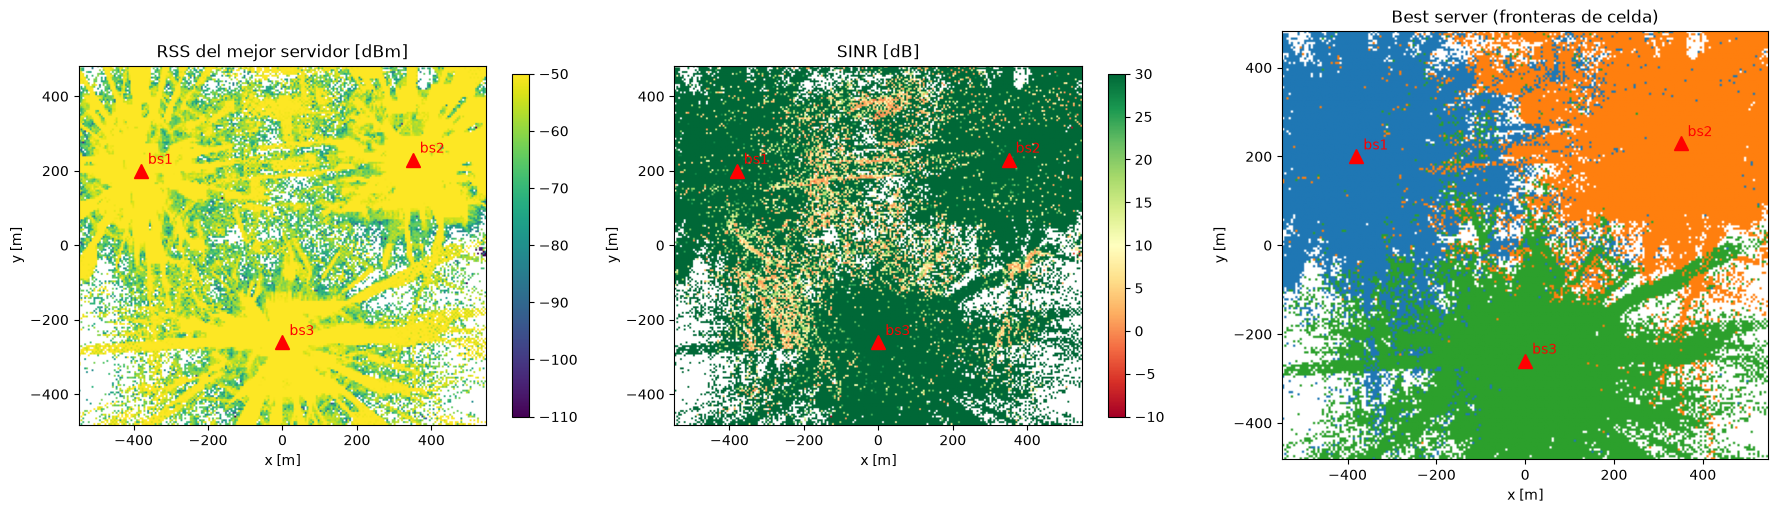

In [27]:
# Los 3 mapas del planificador: RSS, SINR, best server
cc = np.array(rm3.cell_centers)                 # [ny, nx, 3]
extent = [cc[..., 0].min(), cc[..., 0].max(),
          cc[..., 1].min(), cc[..., 1].max()]

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

im0 = axs[0].imshow(rss_dbm, origin="lower", extent=extent, cmap="viridis",
                    vmin=-110, vmax=-50)
axs[0].set_title("RSS del mejor servidor [dBm]")
plt.colorbar(im0, ax=axs[0], shrink=0.8)

im1 = axs[1].imshow(sinr_db, origin="lower", extent=extent, cmap="RdYlGn",
                    vmin=-10, vmax=30)
axs[1].set_title("SINR [dB]")
plt.colorbar(im1, ax=axs[1], shrink=0.8)

im2 = axs[2].imshow(np.where(covered, best, np.nan), origin="lower",
                    extent=extent, cmap="tab10", vmin=0, vmax=9)
axs[2].set_title("Best server (fronteras de celda)")

for ax in axs:
    for i, (name, pos) in enumerate(sites.items()):
        ax.plot(pos[0], pos[1], "r^", markersize=10)
        ax.annotate(name, (pos[0], pos[1]), color="red",
                    xytext=(5, 5), textcoords="offset points")
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")

plt.tight_layout()
plt.savefig("resultados/red_3bs_mapas.png", dpi=120, bbox_inches="tight")
plt.show()

In [28]:
# Vista 3D de la red con el mapa SINR sobre la ciudad
cam3 = Camera(position=[0.0, -700.0, 500.0], look_at=[0.0, 0.0, 0.0])
scene.render_to_file(camera=cam3, filename="resultados/red_3bs_3d.png",
                     radio_map=rm3, rm_metric="sinr",
                     resolution=(1280, 720))
print("escrito red_3bs_3d.png")

escrito red_3bs_3d.png


triángulos de edificios: 11335


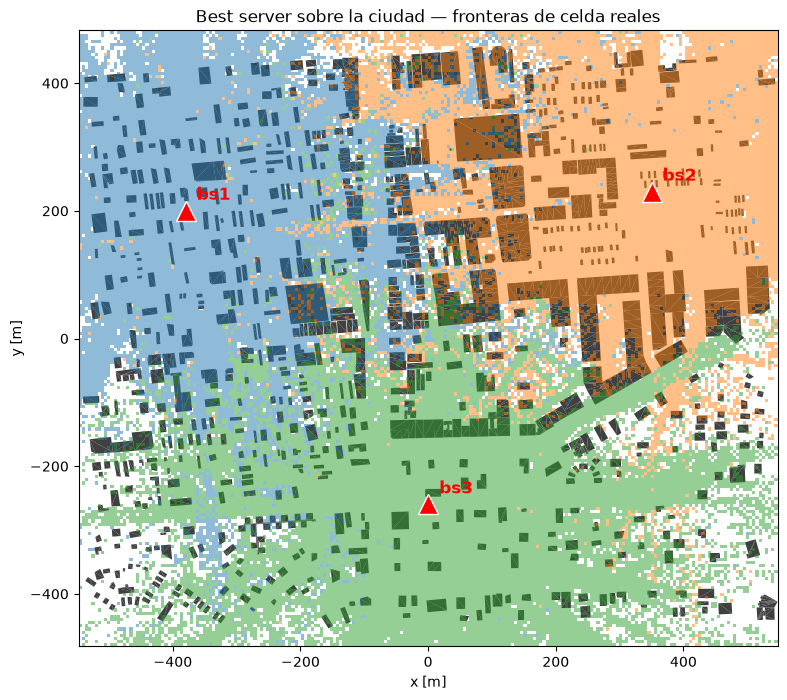

In [29]:
# Best server SOBRE la ciudad — huellas de edificios desde la geometría
# de la escena (proyección 2D de los triángulos): alineación exacta,
# sin problemas de cámara.
import mitsuba as mi
from matplotlib.collections import PolyCollection

tris = []
for shape in scene.mi_scene.shapes():
    params = mi.traverse(shape)
    if "vertex_positions" not in params:
        continue
    V = np.array(params["vertex_positions"]).reshape(-1, 3)
    F = np.array(params["faces"]).reshape(-1, 3)
    if V[:, 2].max() < 1.0:      # saltar el plano del suelo si existe
        continue
    tris.append(V[F][:, :, :2])  # triángulos proyectados al plano XY
tris = np.concatenate(tris)
print("triángulos de edificios:", len(tris))

fig, ax = plt.subplots(figsize=(14, 8))
ax.add_collection(PolyCollection(tris, facecolor="0.25", edgecolor="none",
                                 zorder=1))
ax.imshow(np.where(covered, best, np.nan), origin="lower", extent=extent,
          cmap="tab10", vmin=0, vmax=9, alpha=0.5, zorder=2)
for name, pos in sites.items():
    ax.plot(pos[0], pos[1], "r^", markersize=14, markeredgecolor="white",
            zorder=3)
    ax.annotate(name, (pos[0], pos[1]), color="red", fontsize=12,
                fontweight="bold", xytext=(8, 8), textcoords="offset points")
ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
ax.set_aspect("equal")
ax.set_title("Best server sobre la ciudad — fronteras de celda reales")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
plt.savefig("resultados/best_server_ciudad.png", dpi=120, bbox_inches="tight")
plt.show()

## Parte 3 — Mapa de throughput

La cobertura dice "hay señal"; el throughput dice **lo que el usuario siente**.
Shannon por celda: $C = B \log_2(1+\mathrm{SINR})$, con techo de eficiencia
espectral práctico (~7.4 bit/s/Hz ≈ 256-QAM) y 80% de utilización.

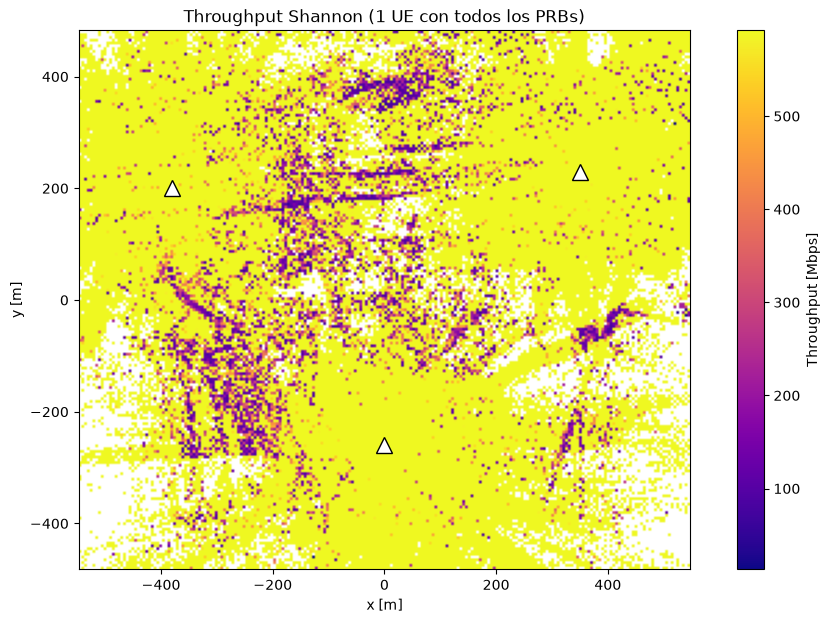

mediana: 592 Mbps | p5 (borde): 151 Mbps | p95 (cerca BS): 592 Mbps


In [30]:
B = 100e6                                     # 100 MHz — canal n78 típico
se = np.log2(1 + np.where(covered, sinr_best, 0))
se = np.minimum(se, 7.4)                      # techo de modulación práctica
thr_mbps = 0.8 * B * se / 1e6                 # 80% utilización (overhead)

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(np.where(covered, thr_mbps, np.nan), origin="lower",
               extent=extent, cmap="plasma")
plt.colorbar(im, ax=ax, label="Throughput [Mbps]")
for name, pos in sites.items():
    ax.plot(pos[0], pos[1], "w^", markersize=12, markeredgecolor="black")
ax.set_title("Throughput Shannon (1 UE con todos los PRBs)")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
plt.savefig("resultados/mapa_throughput.png", dpi=120, bbox_inches="tight")
plt.show()

v = thr_mbps[covered]
print(f"mediana: {np.median(v):.0f} Mbps | p5 (borde): {np.percentile(v,5):.0f}"
      f" Mbps | p95 (cerca BS): {np.percentile(v,95):.0f} Mbps")

## Parte 4 — Drive test virtual y handover

Un UE recorre una calle de oeste a este. En cada punto medimos el RSS de las
3 BS (directo del radio map — sin ray tracing extra). Donde las curvas se
cruzan vive el **handover**: el evento A3 dispara cuando la vecina supera a la
servidora por un margen (histéresis) sostenido un tiempo (time-to-trigger).
Sin histéresis → ping-pong.

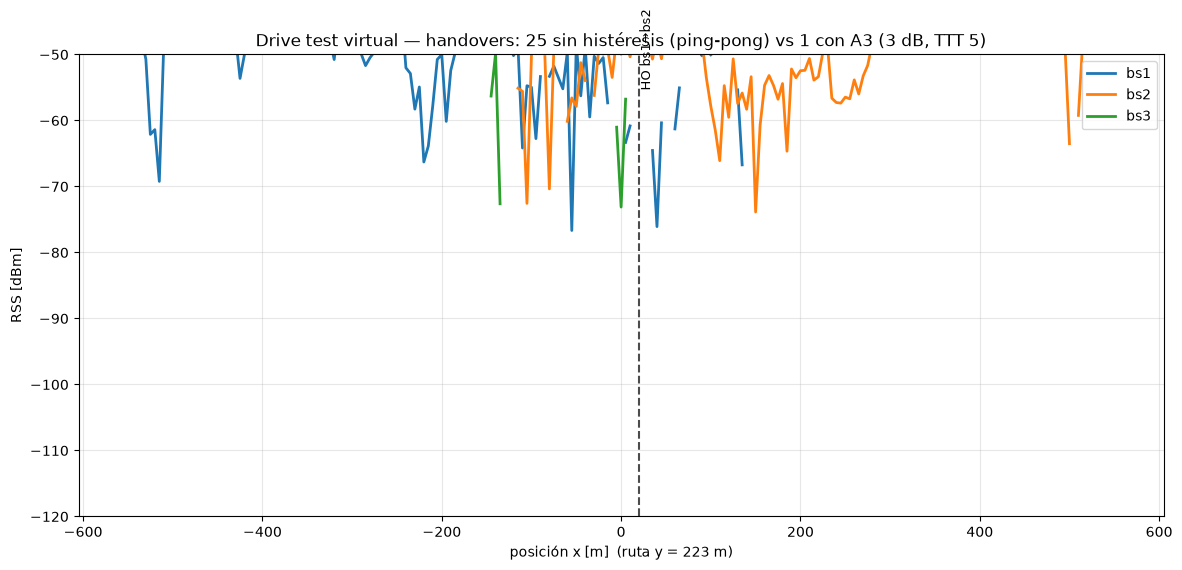

In [31]:
# Ruta: la fila del mapa con MÁS celdas cubiertas dentro de la franja urbana
# (= una calle transitable; una línea arbitraria cruzaría interiores de manzana)
franja = np.where((cc[:, 0, 1] > 50) & (cc[:, 0, 1] < 350))[0]
fila = franja[np.argmax((rss.max(axis=0) > 0)[franja].sum(axis=1))]
y_ruta = float(cc[fila, 0, 1])

xs = np.linspace(-550.0, 550.0, 221)          # paso 5 m = una celda del mapa
cols = np.array([np.argmin(np.abs(cc[0, :, 0] - x)) for x in xs])
rss_ruta_w = rss[:, fila, cols]                        # [3, N] en W

rss_ruta = 10*np.log10(np.where(rss_ruta_w > 0, rss_ruta_w, np.nan)) + 30
rss_a3 = np.where(np.isnan(rss_ruta), -170.0, rss_ruta)   # relleno para el A3

def simular_a3(rss_db, hyst_db, ttt):
    """Evento A3: cambia de servidora si otra la supera por hyst_db
    durante ttt muestras consecutivas. Devuelve lista de (índice, de, a)."""
    serv = int(np.argmax(rss_db[:, 0]))
    contador, candidata, eventos = 0, serv, []
    for n in range(rss_db.shape[1]):
        mejor = int(np.argmax(rss_db[:, n]))
        if mejor != serv and rss_db[mejor, n] > rss_db[serv, n] + hyst_db:
            contador = contador + 1 if mejor == candidata else 1
            candidata = mejor
            if contador >= ttt:
                eventos.append((n, serv, mejor))
                serv, contador = mejor, 0
        else:
            contador = 0
    return eventos

ho_sin = simular_a3(rss_a3, hyst_db=0.0, ttt=1)   # sin protección
ho_con = simular_a3(rss_a3, hyst_db=3.0, ttt=5)   # A3 típico: 3 dB, TTT 5

fig, ax = plt.subplots(figsize=(14, 6))
for i, name in enumerate(sites):
    ax.plot(xs, rss_ruta[i], label=name, linewidth=2)   # NaN = hueco, no pico
for n, de, a in ho_con:
    ax.axvline(xs[n], color="k", linestyle="--", alpha=0.7)
    ax.annotate(f"HO {list(sites)[de]}→{list(sites)[a]}", (xs[n], -55),
                rotation=90, fontsize=9)
ax.set_ylim(-120, -50)
ax.set_xlabel(f"posición x [m]  (ruta y = {y_ruta:.0f} m)")
ax.set_ylabel("RSS [dBm]")
ax.set_title(f"Drive test virtual — handovers: {len(ho_sin)} sin histéresis "
             f"(ping-pong) vs {len(ho_con)} con A3 (3 dB, TTT 5)")
ax.legend(); ax.grid(alpha=0.3)
plt.savefig("resultados/drive_test.png", dpi=120, bbox_inches="tight")
plt.show()

## Parte 5 — LTE (2.1 GHz) vs 5G (3.5 GHz): misma red, otra física

Mismos sitios, misma potencia — solo cambia la frecuencia portadora. A 2.1 GHz
(banda 4G clásica) la pérdida de propagación es ~4.4 dB menor
($20\log_{10}(3.5/2.1)$) y la difracción ayuda más. La lección de diseño: una
red planificada para LTE **no cubre igual** cuando se re-usa el sitio para 5G
en 3.5 GHz — por eso 5G necesita más sitios o más ganancia de antena.

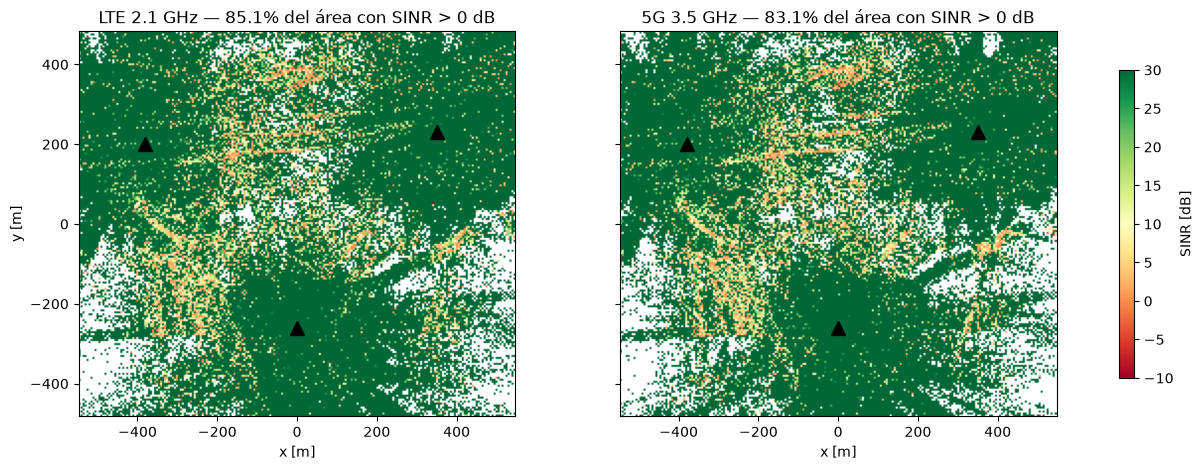

cobertura LTE: 85.1% | 5G: 83.1% | déficit 5G: 2.0 puntos con los MISMOS sitios


In [32]:
# Misma red a 2.1 GHz (LTE); calidad consolidada para comparar en serio
scene.frequency = 2.1e9
rm_lte = RadioMapSolver()(scene, max_depth=5, cell_size=(5.0, 5.0),
                          samples_per_tx=10**6, diffuse_reflection=True)
scene.frequency = 3.5e9                       # restaurar SIEMPRE

pct_lte, pct_5g = cobertura_pct(rm_lte), cobertura_pct(rm3)
sinr_lte = np.array(rm_lte.sinr).max(axis=0)
sinr_lte_db = 10*np.log10(np.where(sinr_lte > 0, sinr_lte, np.nan))

fig, axs = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, mapa, titulo in [(axs[0], sinr_lte_db, f"LTE 2.1 GHz — {pct_lte:.1f}%"),
                          (axs[1], sinr_db,     f"5G 3.5 GHz — {pct_5g:.1f}%")]:
    im = ax.imshow(mapa, origin="lower", extent=extent, cmap="RdYlGn",
                   vmin=-10, vmax=30)
    ax.set_title(titulo + " del área con SINR > 0 dB")
    for name, pos in sites.items():
        ax.plot(pos[0], pos[1], "k^", markersize=10)
    ax.set_xlabel("x [m]")
axs[0].set_ylabel("y [m]")
plt.colorbar(im, ax=axs, shrink=0.8, label="SINR [dB]")
plt.savefig("resultados/lte_vs_5g.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"cobertura LTE: {pct_lte:.1f}% | 5G: {pct_5g:.1f}% | "
      f"déficit 5G: {pct_lte-pct_5g:.1f} puntos con los MISMOS sitios")

## Parte 6 — El enlace que de verdad limita: uplink

La BS grita con 44 dBm; el UE susurra con 23 dBm. La ganancia de trayecto es
**recíproca** (misma frecuencia TDD), así que reutilizamos el `path_gain` del
mapa consolidado sin trazar ni un rayo más. El UE compensa parcialmente
transmitiendo en menos ancho de banda (5 MHz asignados vs 100) y la BS tiene
mejor figura de ruido — pero aún así el borde de celda lo define casi siempre
la subida.

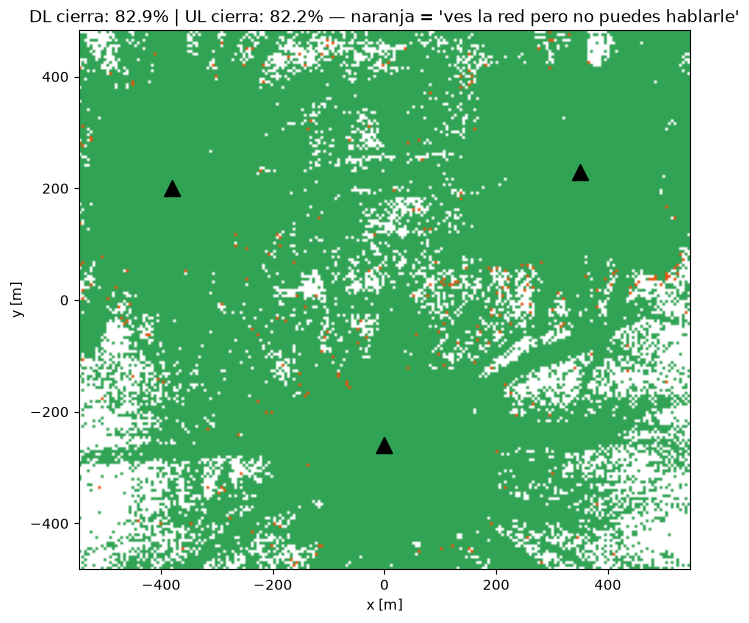

In [33]:
# Presupuestos de enlace por celda del mapa (reciprocidad TDD: mismo path gain)
pg = np.array(rm3.path_gain).max(axis=0)               # mejor servidor, lineal
pg_db = 10*np.log10(np.where(pg > 0, pg, np.nan))

N_dl = -174 + 10*np.log10(100e6) + 9    # ruido UE:  100 MHz, NF 9 dB
N_ul = -174 + 10*np.log10(5e6)   + 5    # ruido BS:  5 MHz asignados, NF 5 dB

snr_dl = 44 + pg_db - N_dl              # dB
snr_ul = 23 + pg_db - N_ul

ok_dl, ok_ul = snr_dl > 0, snr_ul > 0
pct_dl = np.nanmean(np.where(np.isnan(snr_dl), False, ok_dl)) * 100
pct_ul = np.nanmean(np.where(np.isnan(snr_ul), False, ok_ul)) * 100

# mapa categórico: 0 = nada, 1 = solo DL cierra (zona fantasma), 2 = ambos
estado = np.where(np.isnan(snr_dl), 0, ok_dl.astype(int) + ok_ul.astype(int))

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(estado, origin="lower", extent=extent,
               cmap=plt.matplotlib.colors.ListedColormap(
                   ["white", "#e6550d", "#31a354"]), vmin=0, vmax=2)
for name, pos in sites.items():
    ax.plot(pos[0], pos[1], "k^", markersize=12)
ax.set_title(f"DL cierra: {pct_dl:.1f}% | UL cierra: {pct_ul:.1f}% — "
             "naranja = 'ves la red pero no puedes hablarle'")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
plt.savefig("resultados/uplink_vs_downlink.png", dpi=120, bbox_inches="tight")
plt.show()

## Parte 7 — Densificación: ¿cuántos sitios necesita la meta?

Agregamos BS candidatas una por una (colocadas en los huecos del best-server)
y medimos cobertura tras cada adición. La curva muestra **rendimientos
decrecientes**: cada sitio nuevo cuesta lo mismo y aporta menos. Comparar con
la meta (95%) responde la pregunta de negocio: ¿cuántos sitios comprar?

Todos los puntos de la curva se calculan con la misma calidad que la línea
base (10⁶ muestras) — mezclar calidades de muestreo hace la curva
incomparable.

4 sitios → 89.1%
5 sitios → 94.0%
6 sitios → 96.1%


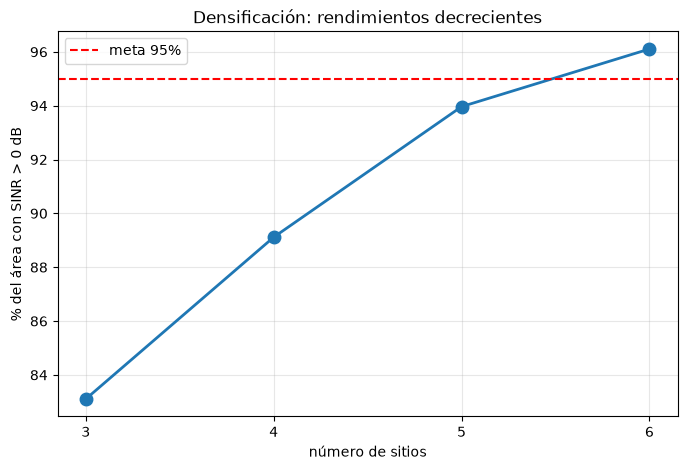

In [34]:
# Sitios candidatos en los huecos blancos del mapa best-server
extras = {
    "bs4": [ 520.0, -260.0, 30.0],   # hueco este-sur
    "bs5": [-560.0, -280.0, 30.0],   # hueco oeste-sur
    "bs6": [  60.0,  360.0, 30.0],   # hueco norte-centro
}

# misma calidad que la línea base — curva comparable con el 71.2%
curva = {3: cobertura_pct(rm3)}
for k, (name, pos) in enumerate(extras.items(), start=4):
    scene.add(Transmitter(name, position=pos, power_dbm=P_TX_DBM))
    rm_tmp = RadioMapSolver()(scene, max_depth=5, cell_size=(5.0, 5.0),
                              samples_per_tx=10**6, diffuse_reflection=True)
    curva[k] = cobertura_pct(rm_tmp)
    print(f"{k} sitios → {curva[k]:.1f}%")

for name in extras:                    # restaurar la red base de 3 sitios
    scene.remove(name)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(curva), list(curva.values()), "o-", linewidth=2, markersize=9)
ax.axhline(95, color="r", linestyle="--", label="meta 95%")
ax.set_xticks(list(curva))
ax.set_xlabel("número de sitios")
ax.set_ylabel("% del área con SINR > 0 dB")
ax.set_title("Densificación: rendimientos decrecientes")
ax.legend(); ax.grid(alpha=0.3)
plt.savefig("resultados/densificacion.png", dpi=120, bbox_inches="tight")
plt.show()

## Parte 8 — MIMO sobre Lima: rank y delay spread medidos, no sorteados

Sesión 06 sorteaba $\mathbf{H}$ de un modelo Rayleigh. Aquí la **medimos** con
ray tracing: arrays 2×2 en ambos extremos → $\mathbf{H}$ 4×4 por punto → SVD →
condicionamiento $\kappa = \sigma_1/\sigma_2$. Donde el entorno mezcla
trayectos (scattering rico) hay multiplexación; donde domina LoS puro, el
canal es rank 1 aunque tenga 4 antenas.

Del mismo trazado sale el **delay spread RMS** por punto → ¿alcanza el CP de
la numerología? (Sesión 03: CP normal a SCS 30 kHz ≈ 2.3 µs).

In [35]:
# Arrays MIMO 2×2 en ambos extremos y una rejilla de UEs de medición
scene.tx_array = PlanarArray(num_rows=2, num_cols=2,
                             vertical_spacing=0.5, horizontal_spacing=0.5,
                             pattern="iso", polarization="V")
scene.rx_array = scene.tx_array

scene.remove("rx")                               # el UE suelto de la Parte 1
gx = np.arange(-600.0, 601.0, 100.0)
gy = np.arange(-350.0, 351.0, 100.0)
# float() nativo: mi.Point3f no acepta np.float64
puntos = [(float(x), float(y)) for y in gy for x in gx]   # 13×8 = 104 UEs
for i, (x, y) in enumerate(puntos):
    scene.add(Receiver(f"g{i}", position=[x, y, 1.5]))

# ponytail: depth 3 y rejilla de 100 m para acotar CPU; afinar para la clase
paths8 = PathSolver()(scene, max_depth=3)
a8, tau8 = np.array(paths8.cir()[0]), np.array(paths8.cir()[1])
a8 = a8[0] + 1j*a8[1]        # Dr.Jit entrega [real/imag, ...] en numpy
print("shape a8:", a8.shape, "| shape tau8:", tau8.shape)

shape a8: (104, 4, 3, 4, 17, 1) | shape tau8: (104, 3, 17)


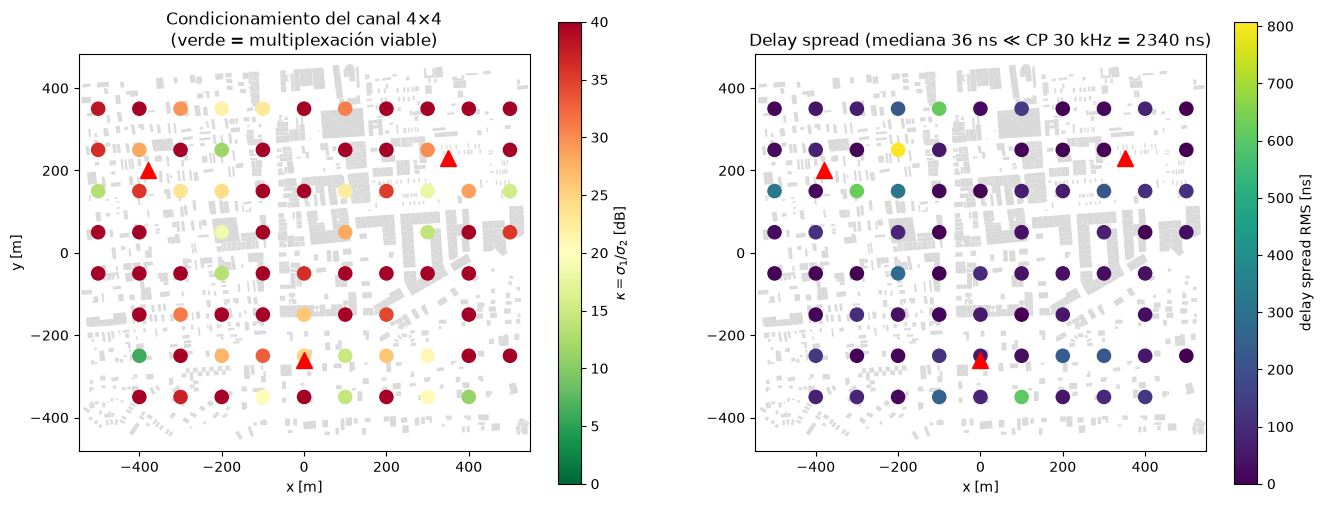

In [36]:
# Por UE: H 4×4 con su BS servidora → SVD → κ; y delay spread RMS
# a8: [rx, ant_rx, tx, ant_tx, paths, t] — tau8: [rx, tx, paths]
kappa_db, ds_ns, xs_p, ys_p = [], [], [], []
for r, (x, y) in enumerate(puntos):
    # BS servidora según el radio map consolidado
    fila_ = np.argmin(np.abs(cc[:, 0, 1] - y))
    col_  = np.argmin(np.abs(cc[0, :, 0] - x))
    srv = best[fila_, col_]

    H = a8[r, :, srv, :, :, 0].sum(axis=-1)      # suma de trayectos → H 4×4
    p_tray = np.abs(a8[r, :, srv, :, :, 0]).sum(axis=(0, 1))**2
    t_tray = tau8[r, srv]
    ok = (t_tray >= 0) & (p_tray > 0)
    if not ok.any() or np.abs(H).max() == 0:
        continue
    sv = np.linalg.svd(H, compute_uv=False)
    kappa_db.append(20*np.log10(sv[0]/max(sv[1], 1e-12)))
    t, p = t_tray[ok], p_tray[ok]
    t_med = (p*t).sum()/p.sum()
    ds_ns.append(np.sqrt((p*(t-t_med)**2).sum()/p.sum())*1e9)
    xs_p.append(x); ys_p.append(y)

fig, axs = plt.subplots(1, 2, figsize=(16, 6))
sc0 = axs[0].scatter(xs_p, ys_p, c=kappa_db, s=90, cmap="RdYlGn_r",
                     vmin=0, vmax=40)
plt.colorbar(sc0, ax=axs[0], label=r"$\kappa = \sigma_1/\sigma_2$ [dB]")
axs[0].set_title("Condicionamiento del canal 4×4\n(verde = multiplexación viable)")

sc1 = axs[1].scatter(xs_p, ys_p, c=ds_ns, s=90, cmap="viridis")
plt.colorbar(sc1, ax=axs[1], label="delay spread RMS [ns]")
axs[1].set_title(f"Delay spread (mediana {np.median(ds_ns):.0f} ns "
                 "≪ CP 30 kHz = 2340 ns)")

for ax in axs:
    ax.add_collection(PolyCollection(tris, facecolor="0.85",
                                     edgecolor="none", zorder=0))
    for name, pos in sites.items():
        ax.plot(pos[0], pos[1], "r^", markersize=11, zorder=3)
    ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
    ax.set_aspect("equal"); ax.set_xlabel("x [m]")
axs[0].set_ylabel("y [m]")
plt.savefig("resultados/rank_delayspread.png", dpi=120, bbox_inches="tight")
plt.show()

# limpieza: quitar la rejilla de medición
for i in range(len(puntos)):
    scene.remove(f"g{i}")